# FANCY TITLE HERE

**42186 Model-based Machine Learning — final project, group submission.**

This notebook is the single source of truth for our model comparison. It takes the preprocessed Swedish forest dataset (described in the accompanying report) and turns it into a clean modelling support, then trains and compares a sequence of Bayesian models of increasing complexity on the same train/test split.

### What we are predicting

For each $12.5\,\mathrm{m} \times 12.5\,\mathrm{m}$ pixel of forest in a $5\,\mathrm{km} \times 5\,\mathrm{km}$ area of northern Skåne, we predict per-pixel **growth in stem volume between two airborne-lidar inventory cycles** roughly a decade apart:

$$
\Delta V \;=\; \texttt{volume\_t2} \;-\; \texttt{volume\_t1} \quad [\mathrm{m^3/ha}].
$$

The covariates are the cycle-1 forest state (height, diameter, basal area, volume, biomass, vegetation ratio), local hydrology (soil moisture, log-transformed flow accumulation), and a centred-log-ratio (CLR) encoding of the SLU per-species volumes. The PGM and feature rationale are in §3 of the report.

### How this notebook is laid out

| § | What it contains | Why it's here |
|---|---|---|
| 1 | Load the preprocessed CSV, rename Swedish columns to English, drop the identically-zero lodgepole-pine column, and drop non-forest / lake / disturbed pixels via `is_stable_forest`. | Defines the support on which a Gaussian likelihood is well-posed and gives every column a readable name. |
| 2 | Build BK-cell-disjoint train/test splits across a nested scaling grid (`n_cells ∈ {5, 25, 50, all}`). | We need honest evaluation — pixels inside one BK indexruta cell are near-identical, so a random split leaks. The scaling grid lets us read how each model handles "more data of the same kind". |
| 3 | Engineer the 16-column 'standard' feature matrix and the volume-growth target. | Decouples feature choice from any single model. |
| 4 | `slice_step(n_cells)` — one call returns standardised train/test matrices for any scaling step. | Each model below uses the *same* split and the *same* preprocessing, so model differences are not confounded by preprocessing differences. |
| 5 | Evaluation utilities (RMSE / MAE / Bias / R² / correlation + Moran's I on test residuals). | Moran's I detects spatial autocorrelation that the model failed to absorb. This is the diagnostic that justifies adding spatial structure to a model. |
| 6 | Point-estimate baselines: **OLS** (MLE of §7.1's likelihood) and **HistGradientBoosting** (a flexible nonlinear tree ensemble), both across the scaling grid. | OLS is the linear point-accuracy floor; GBM is the nonlinear point-accuracy ceiling. §7's Bayesian models have to justify themselves against both. |
| 7 | Bayesian models, smallest to largest: BLR (VI + MCMC), heteroscedastic linear, hierarchical (random intercept), spatial-lag, SAR, BNN, GP variants. | This is the comparison the report's "Models" section discusses. Each one inherits §4–§5 unchanged. |
| 8 | Diagnostics and sanity checks — generative recovery, ELBO traces, inference-method agreement. | **The course brief flags these explicitly.** |

In [1]:
from __future__ import annotations
from pathlib import Path
import json
import urllib.request

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score

SEED = 42
np.random.seed(SEED)

# Canonical dataset for this notebook: 5 km × 5 km AOI, preprocessed,
# already restricted spatially. See the report's data section for how it
# was derived from the raster pipeline.
CSV_PATH = Path("out_5km_idx_preprocessed.csv")
CSV_URL = (
    "https://github.com/Somon8/mbml-forest-pipeline/"
    "releases/download/v2.0-data-5km/out_5km_idx_preprocessed.csv"
)
CACHE_DIR = Path("cache")
CACHE_DIR.mkdir(exist_ok=True)
SPLITS_JSON = CACHE_DIR / "splits_5km.json"

if not CSV_PATH.exists():
    print(f"CSV missing — downloading from {CSV_URL} ...")
    urllib.request.urlretrieve(CSV_URL, CSV_PATH)
    print(f"  → wrote {CSV_PATH} ({CSV_PATH.stat().st_size/1e6:.0f} MB)")

## 1. Load and filter

The CSV (`out_5km_idx_preprocessed.csv`) is the preprocessed Swedish-forest dataset at $12.5\,\mathrm{m}$ resolution, restricted to the $5\,\mathrm{km} \times 5\,\mathrm{km}$ AOI we use for modelling. The raster→tabular pipeline that produced it lives outside this notebook and is described in the report's data section.

One filter is applied here:

- **`is_stable_forest`** drops pixels that are non-forest in either inventory cycle, are water (lakes), or lost biomass / height / volume between cycles. This leaves the support on which volume growth ($\Delta V$) is *defined, continuous, and non-negative* — modelling outside this support would force a Gaussian likelihood to absorb a large zero spike for non-forest and a separate negative mass for disturbance, which is exactly the miscalibration the report flags as a structural property of the data.

In [2]:
# Swedish raster column names → readable English.
RENAME_MAP = {
    # Skogliga grunddata, cycle 1 ("omdrev 1")
    "biomassa_omdrev1":         "biomass_t1",
    "grundyta_omdrev1":         "basal_area_t1",
    "medeldiameter_omdrev1":    "mean_diameter_t1",
    "medelhojd_omdrev1":        "mean_height_t1",
    "p95_omdrev1":              "p95_height_t1",
    "vegetationskvot_omdrev1":  "veg_ratio_t1",
    "volym_omdrev1":            "volume_t1",
    # Skogliga grunddata, cycle 2 ("omdrev 2")
    "biomassa_omdrev2":         "biomass_t2",
    "grundyta_omdrev2":         "basal_area_t2",
    "medeldiameter_omdrev2":    "mean_diameter_t2",
    "medelhojd_omdrev2":        "mean_height_t2",
    "p95_omdrev2":              "p95_height_t2",
    "vegetationskvot_omdrev2":  "veg_ratio_t2",
    "volym_omdrev2":            "volume_t2",
    # Hydrology, soil and per-pixel canopy
    "flodesackumulering":       "flow_accumulation",
    "markfuktighet":            "soil_moisture",
    "markfuktighet_klassad":    "soil_moisture_class",
    "tradhojd":                 "tree_height",
    # SLU Skogskarta — totals and per-species volumes
    "slu_skogskarta_biomassa":       "slu_total_biomass",
    "slu_skogskarta_grundyta":       "slu_total_basal_area",
    "slu_skogskarta_medeldiameter":  "slu_total_mean_diameter",
    "slu_skogskarta_volym":          "slu_total_volume",
    "slu_skogskarta_gran_volym":     "spruce_volume",
    "slu_skogskarta_tall_volym":     "pine_volume",
    "slu_skogskarta_bjork_volym":    "birch_volume",
    "slu_skogskarta_ek_volym":       "oak_volume",
    "slu_skogskarta_bok_volym":      "beech_volume",
    "slu_skogskarta_ovrigt_volym":   "other_species_volume",
    # `slu_skogskarta_contorta_volym` is identically zero on this AOI and is
    # dropped entirely below — no rename needed.
}

df_raw = pd.read_csv(CSV_PATH, low_memory=False)
df_raw = df_raw.rename(columns=RENAME_MAP)
df_raw = df_raw.drop(columns=["slu_skogskarta_contorta_volym"], errors="ignore")
print(f"raw rows           : {len(df_raw):>8,}  ({df_raw['x'].nunique()} × {df_raw['y'].nunique()} grid)")

df = df_raw[df_raw["is_stable_forest"].astype(bool)].reset_index(drop=True)
print(f"stable-forest rows : {len(df):>8,}  ({100*len(df)/len(df_raw):.1f}% of grid)")
print(f"unique BK cells    : {df['BK'].nunique():>8,}")

raw rows           :  160,000  (400 × 400 grid)
stable-forest rows :   63,073  (39.4% of grid)
unique BK cells    :      121


**Reading the output.** The `is_stable_forest` filter removes roughly 60% of pixels — the AOI is a mixed landscape of forest stands, roads, fields, lakes, and recent clear-cuts. The ~63 000 surviving pixels span 121 BK indexruta cells, which become the unit of the train/test split in the next section.

## 2. BK-cell-disjoint splits on a nested scaling grid

**Why splitting by BK indexruta cell.** Skogsstyrelsen publishes a $500\,\mathrm{m} \times 500\,\mathrm{m}$ administrative grid (the *Sverige-indexruta*); every pixel in our CSV is labelled with the BK cell that contains it. Pixels inside one BK cell are near-identical — same forest stand, same management history, same soil class — so a random pixel split would put a held-out pixel next to its ~1 600 quasi-twins on the training side and inflate R² by tens of percent without telling us anything generalisable. **Splitting by BK cell** prevents that within-cell leakage: every test pixel is in a BK cell that contains no training pixel.

**What it does and does not solve.** BK-disjoint splits kill within-cell leakage. They do *not* kill across-cell spatial autocorrelation — two adjacent BK cells are still correlated (similar elevation, similar species mix). The Moran's I statistic in §5 measures the residual autocorrelation a model failed to absorb, and motivates the spatial-component models in §7.

**How train and test are built.** From the 121 BK cells in the AOI:

- **24 cells (≈ 20 %)** are picked once by a seeded random draw and held out as the **test set**. These cells — and every pixel inside them — are never seen by any model during training, at any scaling step.
- **97 cells (the remainder)** form the **training pool**, kept in a seeded random order.

The same 24-cell test set is used everywhere downstream, so test pixels are *constant* across models *and* across scaling steps. RMSEs are therefore directly comparable.

**Why a *nested* scaling grid.** A scaling step `n_cells = k` trains on the **first $k$ cells of the 97-cell training pool**, against the same 24-cell test set. Because the pool is ordered once and never reshuffled, the 5 cells used at `n_cells = 5` are a strict subset of the 25 used at `n_cells = 25`, which are a strict subset of 50, and so on up to `n_cells = 'all'` ($= 97$). The scaling axis therefore measures "more of the same kind of data" rather than "different draw of the same size" — exactly the right experiment to read whether a model is data-starved or capacity-bound.

The grid auto-shrinks to fit the train-pool size: with 97 training cells, `[5, 25, 50]` plus `'all'` are the scaling choices.

In [3]:
TEST_FRAC = 0.20


def build_splits(df: pd.DataFrame, test_frac: float, seed: int) -> dict:
    rng = np.random.default_rng(seed)
    all_bk = sorted(df["BK"].unique().tolist())
    rng.shuffle(all_bk)
    n_test = int(round(test_frac * len(all_bk)))
    return {
        "test_bk": sorted(all_bk[:n_test]),
        "train_bk_ordered": list(all_bk[n_test:]),
    }


def get_train_bk(splits: dict, n_cells) -> list:
    pool = splits["train_bk_ordered"]
    return list(pool) if n_cells == "all" else list(pool[: int(n_cells)])


if SPLITS_JSON.exists():
    splits = json.loads(SPLITS_JSON.read_text())
    print(f"loaded splits from {SPLITS_JSON}")
else:
    splits = build_splits(df, TEST_FRAC, seed=SEED)
    SPLITS_JSON.write_text(json.dumps(splits))
    print(f"built and saved splits → {SPLITS_JSON}")

# Scaling grid auto-shrinks to fit the train pool — every step except 'all' must be
# strictly smaller than the pool so the nested-subset invariant stays meaningful.
n_pool = len(splits["train_bk_ordered"])
SCALING_GRID = [n for n in [5, 25, 50, 100, 250] if n < n_pool] + ["all"]

print(f"test BK cells : {len(splits['test_bk']):>4}")
print(f"train pool BK : {n_pool:>4}")
print(f"scaling grid  : {SCALING_GRID}")
for n in SCALING_GRID:
    tbk = get_train_bk(splits, n)
    n_pix = df[df["BK"].isin(set(tbk))].shape[0]
    print(f"  n_cells={str(n):>4}  → {len(tbk):>4} BK cells, {n_pix:>7,} pixels")

loaded splits from cache/splits_5km.json
test BK cells :   24
train pool BK :   97
scaling grid  : [5, 25, 50, 'all']
  n_cells=   5  →    5 BK cells,   3,411 pixels
  n_cells=  25  →   25 BK cells,  14,945 pixels
  n_cells=  50  →   50 BK cells,  28,925 pixels
  n_cells= all  →   97 BK cells,  52,184 pixels


In [4]:
# nesting + disjointness sanity checks
subsets = [set(get_train_bk(splits, n)) for n in SCALING_GRID]
for i in range(len(subsets) - 1):
    assert subsets[i].issubset(subsets[i + 1]), f"subset {i} not nested in {i+1}"
test_set = set(splits["test_bk"])
for n, ss in zip(SCALING_GRID, subsets):
    assert not (ss & test_set), f"train at n_cells={n} overlaps test BK"
print("nesting + disjointness: OK")

nesting + disjointness: OK


**Reading the output.** 24 BK cells (~20% of the 121 in the window) are held out for testing once and never seen during training. The remaining 97 are the training pool, drawn in increasing chunks for the scaling axis: 5 → 25 → 50 → 97. The pixel counts roughly track the BK count (~540 pixels per cell after the stable-forest filter).

## 3. Feature matrix and target

**Target — volume growth.** $\Delta V = \texttt{volume\_t2} - \texttt{volume\_t1}$ is the per-pixel change in stem volume between the two inventory cycles, in m³/ha. On the stable-forest support it is non-negative (forest stands gain volume between cycles, never lose it — `delta_neg_volym` pixels are excluded), continuous, and right-skewed. A Gaussian likelihood is a defensible *starting point* — the report and §7 will discuss whether richer likelihoods (heteroscedastic, log-normal, Gamma) calibrate the tail better.

**Features — 16 columns, three logical blocks:**

1. **Forest state at cycle 1 (10 cols, raw):** `biomass_t1`, `basal_area_t1`, `mean_diameter_t1`, `mean_height_t1`, `p95_height_t1`, `veg_ratio_t1`, `volume_t1` (the seven lidar-derived cycle-1 forest summaries), `flow_accumulation` (upstream drainage), `soil_moisture` (SLU soil-moisture index), and `slu_total_biomass` (total above-ground biomass from the SLU Skogskarta product, t/ha). These are the *initial conditions* the model uses to predict growth between cycles. Cycle-2 columns are deliberately **excluded** — they would leak the target.
2. **Species composition (6 cols, CLR-transformed):** the six SLU per-species stem volumes that actually occur on this AOI — `spruce_volume`, `pine_volume`, `birch_volume`, `oak_volume`, `beech_volume`, `other_species_volume`. They sum to the SLU total volume by construction, so they live on the 6-simplex rather than in $\mathbb{R}^6$. The centred log-ratio transform $p_i \mapsto \log(p_i / g(p))$, where $g(p)$ is the row's geometric mean of the species proportions, lifts the block into an unconstrained space where standard linear-model machinery applies cleanly. A small $\varepsilon$ keeps the log finite when a species is locally absent. Lodgepole pine (`slu_skogskarta_contorta_volym`) is identically zero across this AOI and is dropped at load time rather than included via an $\varepsilon$ fallback — it would carry no signal and would distort the geometric mean.

**A subtle leakage point.** `volume_t1` is in the feature block *and* is one of the two ingredients of the target. That's intentional and not leakage: we are explicitly modelling growth conditional on the initial volume, exactly as a textbook growth equation $\Delta V = f(V_1, \text{covariates}) - V_1$ would. The cycle-1 volume is observable a decade before the cycle-2 measurement, so a forecasting model legitimately has it.

**Standardisation happens later.** Both $\mathbf{X}$ and $y$ are mean-centred and unit-scaled inside `slice_step` using **training-set statistics only**, so test pixels never contribute to the standardisation scale. The unstandardised arrays are kept here as the source of truth.

In [5]:
BASE_COLS = [
    "biomass_t1", "basal_area_t1", "mean_diameter_t1",
    "mean_height_t1", "p95_height_t1", "veg_ratio_t1",
    "volume_t1", "flow_accumulation", "soil_moisture",
    "slu_total_biomass",
]
SPECIES_COLS = [
    "spruce_volume", "pine_volume", "birch_volume",
    "oak_volume", "beech_volume", "other_species_volume",
]


def clr_transform(values: np.ndarray, eps: float = 1e-9) -> np.ndarray:
    row_sums = values.sum(axis=1, keepdims=True)
    nz = row_sums.ravel() > 0
    props = np.where(row_sums > 0, values / np.where(row_sums > 0, row_sums, 1.0), 0.0)
    props_safe = np.where(props <= 0, eps, props)
    log_props = np.log(props_safe)
    clr = log_props - log_props.mean(axis=1, keepdims=True)
    clr[~nz] = 0.0
    return clr


X_base = df[BASE_COLS].to_numpy(float)
X_clr = clr_transform(df[SPECIES_COLS].to_numpy(float))
X_all = np.hstack([X_base, X_clr])
FEATURE_NAMES = BASE_COLS + [c + "_clr" for c in SPECIES_COLS]

# Target: per-pixel change in stem volume between inventory cycles (m³/ha).
# is_stable_forest excludes delta_neg_volym, so the target is ≥ 0 on the support.
y_all = (df["volume_t2"] - df["volume_t1"]).to_numpy(float)
coords_all = df[["x", "y"]].to_numpy(float)
bk_all = df["BK"].to_numpy()

print(f"X_all   : {X_all.shape}  ({len(FEATURE_NAMES)} features = {len(BASE_COLS)} base + {len(SPECIES_COLS)} CLR)")
print(f"y_all   : {y_all.shape}  mean={y_all.mean():.2f} m³/ha  std={y_all.std():.2f} m³/ha")
print(f"coords  : {coords_all.shape}")

X_all   : (63073, 16)  (16 features = 10 base + 6 CLR)
y_all   : (63073,)  mean=52.07 m³/ha  std=44.57 m³/ha
coords  : (63073, 2)


**Reading the output.** Design matrix is $\sim\!63\,000 \times 17$. 17 features per pixel, three feature blocks combined as described above. The target's mean ($\sim\!52\,\mathrm{m^3/ha}$) and standard deviation ($\sim\!45\,\mathrm{m^3/ha}$) are both physically plausible for a decade of stem-volume accumulation in Swedish managed forest — typical mean-annual-increment figures of $5{-}10\,\mathrm{m^3/ha/year}$ over $\sim\!10$ years bracket the observed mean. The numbers being signed positive on the stable-forest support also confirms that cycle 2 is genuinely the later inventory cycle.

## 4. `slice_step` — one call returns one scaling step's data

Every model in §6–§7 reads its training and test data through this single helper, to ensure comparability across models.

`slice_step(n_cells)` returns a dict containing:

- `X_train`, `y_train`, `X_test`, `y_test` — **standardised** against training-set mean and standard deviation only;
- `coords_test` — the (x, y) test coordinates, needed for the Moran's I residual diagnostic;
- `y_mean`, `y_std` — the rescaling constants, so a model that predicts in standardised units can be brought back to decimetres for human-readable error metrics.

In [6]:
def slice_step(n_cells):
    train_bk = set(get_train_bk(splits, n_cells))
    test_bk = set(splits["test_bk"])

    tr = np.isin(bk_all, list(train_bk))
    te = np.isin(bk_all, list(test_bk))

    Xtr, ytr = X_all[tr], y_all[tr]
    Xte, yte = X_all[te], y_all[te]
    coords_te = coords_all[te]

    x_mean = Xtr.mean(axis=0)
    x_std = Xtr.std(axis=0) + 1e-8
    y_mean, y_std = float(ytr.mean()), float(ytr.std() + 1e-8)

    Xtr_s = (Xtr - x_mean) / x_std
    Xte_s = (Xte - x_mean) / x_std
    ytr_s = (ytr - y_mean) / y_std
    yte_s = (yte - y_mean) / y_std

    return {
        "X_train": Xtr_s, "y_train": ytr_s,
        "X_test":  Xte_s, "y_test":  yte_s,
        "coords_test": coords_te,
        "y_mean": y_mean, "y_std": y_std,
        "n_train": int(tr.sum()), "n_test": int(te.sum()),
    }

## 5. Evaluation utilities

All metrics are computed in the original units (m³/ha) after un-standardising the predictions, so the numbers are directly comparable to the target's natural scale.

**Point-prediction metrics.** RMSE, MAE, Bias, $R^2$, and correlation are the standard regression scorecard. We report them all because they answer slightly different questions: RMSE penalises large errors quadratically (relevant if growth outliers matter), MAE is robust and unitful (easy to interpret as "typical error in m³/ha"), Bias reveals systematic over/under-prediction, $R^2$ summarises variance explained, and correlation is scale-invariant.

**Moran's I on test residuals.** The diagnostic that justifies most of the spatial structure in §7. It measures whether the residuals $r_i = \hat{y}_i - y_i$ are spatially autocorrelated — whether neighbouring test pixels have similar errors. We use 8 nearest neighbours in projected $(x, y)$ space with row-standardised weights, so the formula simplifies to

$$ I \;=\; \frac{\sum_i z_i \cdot \overline{z_{\,N(i)}}}{\sum_i z_i^2}, \qquad z_i = r_i - \bar r, $$

where $\overline{z_{\,N(i)}}$ is the mean residual over $i$'s 8 nearest test neighbours. The $p$-value comes from a 999-step permutation test: shuffle the residuals on top of the same coordinates many times, recompute $I$, and count how often it exceeds the observed value. The implementation is ~25 lines of `numpy` + `sklearn.NearestNeighbors` so the notebook has no `libpysal` / `esda` dependency.

- $I \approx 0$ with non-significant $p$ ⟹ the model has absorbed the spatial structure; residuals look like noise.
- $I$ substantially positive ⟹ the model is missing spatial information; *some* feature you didn't include or *some* dependency structure you didn't model is varying smoothly across space.

For a covariate-only Bayesian linear model (no spatial component, no hierarchy) we expect $I$ to be **substantially positive** on this data — that's the gap the spatial models in §7 try to close, and is the in-brief motivation (Bayesian Spatial Count Models example) for the spatial-error / correlated-noise term $\phi_i$.

In [7]:
from sklearn.neighbors import NearestNeighbors


def moran_i(values: np.ndarray, coords: np.ndarray, k: int = 8,
            n_permutations: int = 999, seed: int = 42) -> tuple[float, float]:
    """Moran's I on k-NN, row-standardised weights; permutation p-value.

    With row-standardised weights the formula reduces to
        I = sum_i z_i * mean(z_j for j in neighbours_i) / sum_i z_i^2,
    so we never materialise the weight matrix.
    """
    coords = np.asarray(coords)
    values = np.asarray(values).ravel()
    nn = NearestNeighbors(n_neighbors=k + 1).fit(coords)
    _, idx = nn.kneighbors(coords)
    neighbours = idx[:, 1:]  # drop self

    def _i(z: np.ndarray) -> float:
        num = (z * z[neighbours].mean(axis=1)).sum()
        return float(num / (z @ z))

    z_obs = values - values.mean()
    observed = _i(z_obs)

    rng = np.random.default_rng(seed)
    perms = np.fromiter(
        (_i(rng.permutation(z_obs)) for _ in range(n_permutations)),
        dtype=float, count=n_permutations,
    )
    p = (1 + (perms >= observed).sum()) / (1 + n_permutations)
    return observed, float(p)


def evaluate(y_true: np.ndarray, y_pred: np.ndarray,
             coords: np.ndarray | None = None) -> dict:
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    res = y_pred - y_true
    out = {
        "RMSE": float(np.sqrt(np.mean(res ** 2))),
        "MAE":  float(np.mean(np.abs(res))),
        "Bias": float(res.mean()),
        "R2":   float(r2_score(y_true, y_pred)),
        "Corr": float(np.corrcoef(y_true, y_pred)[0, 1]),
    }
    if coords is not None:
        I, p = moran_i(res, coords, k=8)
        out["MoranI"] = I
        out["MoranP"] = p
    return out


# === Model storage ====================================================
# Every fitted model registers its scaling-grid results here so the §8
# comparison table and figures find them without each section duplicating
# the same bookkeeping. Keyed as MODELS[model_name][n_cells].
MODELS: dict[str, dict] = {}


def register_run(name: str, n_cells, *, metrics: dict, n_train: int, n_test: int,
                 coefs_samples: np.ndarray | None = None,
                 sigma_samples: np.ndarray | None = None,
                 elbo_trace: list | None = None,
                 **extras) -> None:
    """Record one (model, n_cells) result for downstream comparisons.

    ``coefs_samples`` is expected to be shape (n_post_samples, n_features + 1),
    with the intercept as column 0. For point-estimate models pass shape
    (1, n_features + 1) or omit.
    """
    MODELS.setdefault(name, {})[n_cells] = {
        "metrics": metrics,
        "n_train": n_train,
        "n_test": n_test,
        "coefs_samples": coefs_samples,
        "sigma_samples": sigma_samples,
        "elbo_trace": elbo_trace,
        **extras,
    }


def all_metrics_df() -> pd.DataFrame:
    """Flatten MODELS into a long DataFrame for the §8 comparison table."""
    rows = []
    for model_name, by_n in MODELS.items():
        for n_cells, payload in by_n.items():
            rows.append({"model": model_name, "n_cells": n_cells,
                         "n_train": payload["n_train"], "n_test": payload["n_test"],
                         **payload["metrics"]})
    return pd.DataFrame(rows)


## 6. Point-estimate baselines — OLS and GBM across the scaling grid

Two reference points that anchor §7 from below. Both produce point estimates only (no uncertainty), and both share the §4 train/test scaffolding, so §7's Bayesian models can be compared on the *exact* same support.

- **OLS (MLE)** fits the *same linear-Gaussian likelihood* §7.1 will then turn into a full posterior. Any §7 model that does *worse* than OLS in point accuracy is a candidate bug — using a prior should at least match using none.
- **HistGradientBoosting (GBM)** is a flexible nonlinear tree ensemble. It stands in for "what would a state-of-the-art non-Bayesian tabular method do?" with no spatial information beyond the features. Any §7 Bayesian model that closes the OLS → GBM gap on RMSE is showing real capacity gains; any that doesn't has to justify itself on *uncertainty*, *hierarchy*, or *spatial structure* instead.

**What to look for in the output table.**

- **OLS RMSE roughly flat across the scaling grid.** With $\sim\!52\,\mathrm{m^3/ha}$ mean and $\sim\!45\,\mathrm{m^3/ha}$ std on the target, an RMSE in the low-to-mid 30s means the linear model captures around two-thirds of the variance and has hit its capacity ceiling.
- **GBM RMSE noticeably lower than OLS,** and (unlike OLS) actually benefitting from more data — that's the signature of a flexible learner that can use additional rows to fit the nonlinear part of the response surface.
- **Bias close to zero** for both. A systematic bias would signal a standardisation bug.
- **Moran's I substantially positive** for both at every scaling step. Neither point-estimate model has any mechanism to absorb spatial autocorrelation. That residual signal is exactly what the §7 spatial models are designed to pick up.

In [8]:
BASELINES = [
    ("OLS",  lambda: LinearRegression()),
    ("GBM",  lambda: HistGradientBoostingRegressor(max_iter=300, random_state=SEED)),
]

rows = []
for n_cells in SCALING_GRID:
    s = slice_step(n_cells)
    for name, make in BASELINES:
        est = make().fit(s["X_train"], s["y_train"])
        # back to m³/ha for interpretable units
        yhat = est.predict(s["X_test"]) * s["y_std"] + s["y_mean"]
        ytrue = s["y_test"] * s["y_std"] + s["y_mean"]
        m = evaluate(ytrue, yhat, coords=s["coords_test"])
        rows.append({
            "n_cells": n_cells, "model": name,
            "n_train": s["n_train"], "n_test": s["n_test"],
            **m,
        })

        # Register for §8. OLS keeps its coefficient vector (so the forest plot
        # can show OLS's point estimate alongside Bayesian intervals); GBM has
        # no meaningful coefficient vector.
        if name == "OLS":
            coefs = np.concatenate([[est.intercept_], est.coef_])[None, :]
        else:
            coefs = None
        register_run(name, n_cells, metrics=m,
                     n_train=s["n_train"], n_test=s["n_test"],
                     coefs_samples=coefs)

baseline_df = pd.DataFrame(rows)
baseline_df


,n_cells,model,n_train,n_test,RMSE,MAE,Bias,R2,Corr,MoranI,MoranP
0,5,OLS,3411,10889,33.904053,24.504033,-0.504463,0.377339,0.615346,0.178815,0.001
1,5,GBM,3411,10889,34.342826,24.203928,0.785039,0.361119,0.612817,0.126723,0.001
2,25,OLS,14945,10889,34.080408,24.594795,1.694985,0.370845,0.611597,0.181387,0.001
3,25,GBM,14945,10889,32.337004,22.678910,0.813424,0.433568,0.659507,0.133927,0.001
4,50,OLS,28925,10889,33.730314,24.507527,1.830426,0.383705,0.621557,0.181319,0.001
5,50,GBM,28925,10889,32.076647,22.716557,1.855575,0.442652,0.667197,0.139866,0.001
6,all,OLS,52184,10889,33.717206,24.517704,1.975810,0.384184,0.621725,0.179158,0.001
7,all,GBM,52184,10889,31.743645,22.409143,1.699278,0.454165,0.675244,0.129272,0.001


**Reading the output.**

- **OLS sits essentially flat** at RMSE $\sim\!33.7$–$34.1\,\mathrm{m^3/ha}$ across the scaling grid, $R^2 \approx 0.38$. More data is not going to help any *linear* model on this feature set — that's the linear point-accuracy ceiling.
- **GBM starts *worse* than OLS at `n_cells=5`** (RMSE $34.3$ vs $33.9$, $R^2$ $0.36$ vs $0.38$) — boosting overfits with only ~3 400 training pixels. From `n_cells=25` onwards GBM overtakes OLS and keeps improving as $N$ grows, ending at RMSE $31.7$ / $R^2 \approx 0.45$ at full $N$. The OLS → GBM gap at full $N$ is roughly **$2\,\mathrm{m^3/ha}$ in RMSE / $0.07$ in $R^2$** — the budget any §7 Bayesian model has to spend if it wants to compete on raw point accuracy alone.
- **Moran's I:** OLS holds at $\sim\!0.18$ across the grid; GBM at $\sim\!0.13$. Trees pick up *some* spatial structure implicitly (forest stands form coherent feature blocks), but residual spatial autocorrelation is still strongly significant ($p = 0.001$) for both methods. Neither model has an explicit spatial component, and the §7 spatial / hierarchical models still have something real to absorb.
- **Bias is small** for both methods at every step, so the standardisation and rescaling round-trip is correct.

The story for §7 is then: a covariate-only BLR (§7.1) should match OLS in RMSE and add credible intervals around it. Hierarchical, spatial-lag, SAR, BNN and GP each have to justify themselves by closing some part of the OLS → GBM gap, dropping Moran's I, or improving calibration over a single point estimate — ideally several at once.

## 7. Bayesian models — building up from simple to complex

This is the comparison the report's *Models* section discusses. Models are introduced in deliberate order, each one motivated by a specific shortcoming of the previous one. Every model uses `slice_step(n_cells)` for its data and `evaluate(...)` for its scoring, and registers its results in `MODELS` so the §8 comparison plots and tables pick them up automatically.

### Story arc

| § | Model | What it adds over the previous | What it tests | Built |
|---|---|---|---|---|
| 7.1 | **Exact conjugate BLR** (closed-form Normal-Inverse-Gamma) | Same linear-Gaussian likelihood as §6 OLS, now with a Gaussian prior on $\beta$ and an Inverse-Gamma prior on $\sigma^2$ — a *full posterior*, not a point estimate. | Provides the **analytical** posterior against which the approximate methods below are checked. | ✓ |
| 7.2 | **BLR via SVI** (Pyro `AutoDiagonalNormal`) | Replaces the closed-form solve with a parametric Gaussian variational approximation; scales to richer models that have no conjugacy. | Does the mean-field VI approximation agree with the exact posterior on this AOI? ELBO trace should be monotone-ish. | ✓ |
| 7.3 | **BLR via MCMC** (Pyro NUTS) | Asymptotically exact samples from $p(\theta\mid D)$ — no parametric approximation. | Inference-method agreement vs. §7.1 (exact) and §7.2 (VI). | ✓ |
| 7.4 | **Heteroscedastic BLR** | Lets the observation variance depend on $\mathbf{X}$, $\sigma^2(\mathbf{X})$, instead of being constant. | Does growth's variance increase with tree size (it should — taller trees have bigger annual variation)? | ✓ |
| 7.5 | Hierarchical (random intercept per BK) | Partial pooling per indexruta cell. | Does the per-BK random-intercept variance dominate residual variance? | planned |
| 7.6 | Spatial-lag covariates | Augments each row with the mean of its rook neighbours' features. | Does explicit local context help over a per-cell intercept? | planned |
| 7.7 | SAR ($y = \rho W y + X \beta + \varepsilon$) | Spatial autoregression of the response on neighbour predictions. | Should drop Moran's I substantially if it's working. | planned |
| 7.8 | BNN with mean-field SVI | Nonlinear $f(\mathbf{X})$. | Closes the OLS → GBM nonlinear gap, with credible intervals. | planned |
| 7.9 | GP variants (exact GP at small `n_cells`, SVGP at full) | Nonparametric prior over functions. | Direct Bayesian alternative to SAR; ARD lengthscales tell us which features matter. | planned |

Each subsection follows the same template:

1. *Why this model* — one-paragraph motivation referencing the previous model's shortcoming or a course concept.
2. *Model definition* — Pyro `model()` / `guide()` (or MCMC kernel) with priors named.
3. *Fit + diagnostics* — ELBO trace for VI, $\hat{R}$ + effective sample size for MCMC.
4. *Predict + evaluate* — through `slice_step` / `evaluate`, results registered into `MODELS`.
5. *Reading the result* — one short markdown cell saying what we learned and what the next model attempts.

### 7.1 Exact conjugate BLR (closed-form reference)

**Why this model first.** The Normal-Inverse-Gamma model has a tractable analytical posterior — we get $p(\theta\mid D)$ in closed form rather than having to approximate it. That makes it the natural *reference posterior* against which §7.2 (SVI) and §7.3 (MCMC) are checked: if either approximation disagrees materially with this one on coefficient means or credible intervals, the disagreement is *inferential*, not *modelling*.

**Priors.** Coefficient prior $\beta \sim \mathcal{N}(0, \tau^2 I)$ with $\tau = 1$ (matches §7.2 / 7.3 in scale); noise variance $\sigma^2 \sim \mathrm{InvGamma}(a_0, b_0)$ with $a_0 = b_0 = 10^{-2}$ — weakly informative, conjugate to the Gaussian likelihood and so closed-form solvable.

**What we return.** 1 000 posterior samples of $\theta = (\alpha, \beta_1, \dots, \beta_d)$ via Cholesky of the posterior covariance; the posterior predictive mean on the original scale; standard metrics including Moran's I on test residuals.

In [9]:
def exact_blr_fit(s, n_samples=1000, tau=1.0, a0=1e-2, b0=1e-2, seed=SEED):
    """Closed-form conjugate Normal-Inverse-Gamma BLR for one `slice_step` payload.

    Returns posterior samples of theta = (alpha, beta), posterior samples of sigma,
    and metrics evaluated on the original (un-standardised) scale.
    """
    rng = np.random.default_rng(seed)
    X_tr = np.asarray(s["X_train"])
    y_tr = np.asarray(s["y_train"]).ravel()
    X_te = np.asarray(s["X_test"])
    y_te = np.asarray(s["y_test"]).ravel()
    n, d = X_tr.shape

    X_tr_d = np.hstack([np.ones((n, 1)), X_tr])
    X_te_d = np.hstack([np.ones((X_te.shape[0], 1)), X_te])
    p = d + 1

    V0_inv = np.eye(p) / (tau ** 2)
    XtX = X_tr_d.T @ X_tr_d
    Xty = X_tr_d.T @ y_tr
    Vn_inv = XtX + V0_inv
    Vn = np.linalg.inv(Vn_inv)
    mu_n = Vn @ Xty

    a_n = a0 + n / 2.0
    b_n = b0 + 0.5 * (y_tr @ y_tr - mu_n @ Vn_inv @ mu_n)

    sigma2_samples = 1.0 / rng.gamma(shape=a_n, scale=1.0 / b_n, size=n_samples)
    L = np.linalg.cholesky(Vn)
    z = rng.normal(size=(n_samples, p))
    theta_samples = mu_n[None, :] + np.sqrt(sigma2_samples)[:, None] * (z @ L.T)

    y_hat_std = (X_te_d @ theta_samples.T).mean(axis=1)
    y_hat  = y_hat_std * s["y_std"] + s["y_mean"]
    y_true = y_te      * s["y_std"] + s["y_mean"]
    metrics = evaluate(y_true, y_hat, coords=s["coords_test"])
    return theta_samples, np.sqrt(sigma2_samples), metrics


rows_exact = []
for n_cells in SCALING_GRID:
    s = slice_step(n_cells)
    theta_samples, sigma_samples, m = exact_blr_fit(s)
    rows_exact.append({"n_cells": n_cells, "n_train": s["n_train"], "n_test": s["n_test"], **m})
    register_run("Exact", n_cells, metrics=m,
                 n_train=s["n_train"], n_test=s["n_test"],
                 coefs_samples=theta_samples,
                 sigma_samples=sigma_samples)

pd.DataFrame(rows_exact)

,n_cells,n_train,n_test,RMSE,MAE,Bias,R2,Corr,MoranI,MoranP
0,5,3411,10889,33.925863,24.516767,-0.555692,0.376538,0.614521,0.181728,0.001
1,25,14945,10889,34.069484,24.594780,1.680093,0.371248,0.611784,0.182227,0.001
2,50,28925,10889,33.732058,24.509542,1.821279,0.383641,0.621469,0.181823,0.001
3,all,52184,10889,33.717820,24.519314,1.970970,0.384161,0.621693,0.179475,0.001


**Reading the output.** The closed-form posterior gives us a clean ground truth for §7.2 / 7.3 to be checked against. We expect RMSE essentially matched to OLS at every scaling step (the priors are weak relative to $N$, so the posterior mean is very close to $\hat\beta_{\text{OLS}}$), with Moran's I unchanged at $\sim\!0.18$ — no spatial structure has been added. What this *does* give us that OLS does not is **posterior samples** for the coefficients, used by §8 for the forest plot.

### 7.2 BLR via stochastic variational inference (SVI)

**Why SVI after exact.** The closed-form posterior in §7.1 is a luxury available only because the model is conjugate. Once we move to hierarchical, spatial, or nonlinear models (§7.5+), there is no closed form. SVI generalises: we pick a parametric family $q(\theta\mid\phi)$ (the *guide*) and minimise the KL divergence $\mathrm{KL}(q\|p)$ via the ELBO. The exact reference in §7.1 lets us *measure* how good the variational approximation is on this same model.

**Implementation.** Pyro's `AutoDiagonalNormal` guide — independent Gaussian variational distribution for each parameter (mean-field). Adam optimiser, $10^{-2}$ learning rate, 2 000 ELBO steps per scaling step. We then draw 1 000 posterior samples from the guide and average predictions, which is mathematically the same as `posterior_mean(alpha) + X @ posterior_mean(beta)` for a linear model.

In [10]:
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, Predictive
from pyro.infer.autoguide import AutoDiagonalNormal
from pyro.optim import Adam


def blr_pyro_model(X, y=None):
    """BLR in Pyro: same linear-Gaussian likelihood / priors as §7.1.

    Prior on intercept: Normal(0, 1)
    Prior on coefficients: Normal(0, 1) (so β is on the same scale as the
        standardised features inside `slice_step`)
    Prior on noise scale: HalfNormal(1)
    """
    n, d = X.shape
    alpha = pyro.sample("alpha", dist.Normal(torch.tensor(0.0), torch.tensor(1.0)))
    beta = pyro.sample(
        "beta",
        dist.Normal(torch.zeros(d), torch.ones(d)).to_event(1),
    )
    sigma = pyro.sample("sigma", dist.HalfNormal(torch.tensor(1.0)))
    mean = alpha + X @ beta
    with pyro.plate("data", n):
        return pyro.sample("y", dist.Normal(mean, sigma), obs=y)


SVI_N_STEPS = 2000
SVI_N_POSTERIOR = 1000

rows_svi = []
for n_cells in SCALING_GRID:
    s = slice_step(n_cells)
    X_tr_t = torch.tensor(s["X_train"], dtype=torch.float32)
    y_tr_t = torch.tensor(s["y_train"], dtype=torch.float32)

    pyro.clear_param_store()
    pyro.set_rng_seed(SEED)
    torch.manual_seed(SEED)
    guide = AutoDiagonalNormal(blr_pyro_model)
    svi = SVI(blr_pyro_model, guide, Adam({"lr": 0.01}), loss=Trace_ELBO())

    elbo_trace = []
    for step in range(SVI_N_STEPS):
        elbo_trace.append(svi.step(X_tr_t, y_tr_t))
    print(f"  [{str(n_cells):>4}] final ELBO = {elbo_trace[-1]:>10.2f}")

    predictive = Predictive(
        blr_pyro_model, guide=guide, num_samples=SVI_N_POSTERIOR,
        return_sites=("alpha", "beta", "sigma"),
    )
    posterior = predictive(X_tr_t, y_tr_t)
    alpha_post = posterior["alpha"].detach().numpy().reshape(-1)
    beta_post  = posterior["beta"].detach().numpy().reshape(SVI_N_POSTERIOR, -1)
    sigma_post = posterior["sigma"].detach().numpy().reshape(-1)
    theta_post = np.concatenate([alpha_post[:, None], beta_post], axis=1)

    y_hat_std = theta_post[:, 0].mean() + s["X_test"] @ theta_post[:, 1:].mean(axis=0)
    y_hat  = y_hat_std    * s["y_std"] + s["y_mean"]
    y_true = s["y_test"]  * s["y_std"] + s["y_mean"]
    m = evaluate(y_true, y_hat, coords=s["coords_test"])

    rows_svi.append({"n_cells": n_cells, "n_train": s["n_train"], "n_test": s["n_test"],
                     "final_elbo": float(elbo_trace[-1]), **m})
    register_run("SVI", n_cells, metrics=m,
                 n_train=s["n_train"], n_test=s["n_test"],
                 coefs_samples=theta_post, sigma_samples=sigma_post,
                 elbo_trace=elbo_trace)

pd.DataFrame(rows_svi)

/Users/mondrup/.venvs/ml42186-proj/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  [   5] final ELBO =    3940.79
  [  25] final ELBO =   17863.88
  [  50] final ELBO =   34323.60
  [ all] final ELBO =   61460.49


,n_cells,n_train,n_test,final_elbo,RMSE,MAE,Bias,R2,Corr,MoranI,MoranP
0,5,3411,10889,3940.787262,34.411064,24.646212,-0.634485,0.358577,0.599071,0.196054,0.001
1,25,14945,10889,17863.883248,34.325163,24.665253,1.142026,0.361776,0.602067,0.196059,0.001
2,50,28925,10889,34323.604630,34.220286,24.622519,1.436543,0.365670,0.605630,0.195992,0.001
3,all,52184,10889,61460.485211,34.229680,24.710715,1.686696,0.365321,0.605700,0.193972,0.001


**Reading the output.** SVI's RMSE / $R^2$ should be within numerical noise of the §7.1 Exact posterior — the linear-Gaussian likelihood doesn't trip up the mean-field guide. If a row shows a meaningful gap, that's a sign the ELBO hasn't converged (rerun with more steps) or the guide is too restrictive for the posterior shape. The `final_elbo` column gives a per-step convergence sanity check. The β posteriors are stored in `MODELS["SVI"][n_cells]["coefs_samples"]` and appear next to Exact in the §8 forest plot.

### 7.3 BLR via MCMC (NUTS)

**Why MCMC after SVI.** SVI's mean-field Gaussian is a *parametric* approximation to the posterior. MCMC, specifically Pyro's No-U-Turn Sampler (NUTS), draws **asymptotically exact** samples from $p(\theta\mid D)$ without imposing a parametric shape. Running it on the same model serves two purposes:

1. **Inference-method agreement** — compare posterior means and 90% credible intervals to §7.1 Exact and §7.2 SVI. Material disagreement on this model would either invalidate the SVI approximation for downstream use, or indicate sampler trouble worth investigating before §7.5+.
2. **Posterior diagnostics** — MCMC gives an honest sample-based posterior usable for posterior predictive checks (§8) on later, non-conjugate models.

**Cost.** NUTS is slow at large $N$; we default to running only the smallest scaling step. Flip `RUN_MCMC_FULL_GRID = True` to run it everywhere — adds a few minutes to the notebook.

In [11]:
from pyro.infer import MCMC, NUTS

RUN_MCMC_FULL_GRID = False  # flip to True to run NUTS at every scaling step

rows_mcmc = []
mcmc_steps = SCALING_GRID if RUN_MCMC_FULL_GRID else [SCALING_GRID[0]]

for n_cells in mcmc_steps:
    s = slice_step(n_cells)
    X_tr_t = torch.tensor(s["X_train"], dtype=torch.float32)
    y_tr_t = torch.tensor(s["y_train"], dtype=torch.float32)

    # Trade off samples vs. compute as N grows.
    if n_cells == 5:
        warmup, draws = 500, 500
    elif n_cells == 25:
        warmup, draws = 400, 400
    elif n_cells == 50:
        warmup, draws = 300, 300
    else:
        warmup, draws = 200, 200

    pyro.clear_param_store()
    pyro.set_rng_seed(SEED)
    torch.manual_seed(SEED)

    kernel = NUTS(blr_pyro_model)
    mcmc = MCMC(kernel, num_samples=draws, warmup_steps=warmup, num_chains=1)
    print(f"  [{str(n_cells):>4}] {warmup} warmup + {draws} draws ...")
    mcmc.run(X_tr_t, y_tr_t)

    posterior   = mcmc.get_samples()
    alpha_post  = posterior["alpha"].detach().numpy()
    beta_post   = posterior["beta"].detach().numpy()
    sigma_post  = posterior["sigma"].detach().numpy()
    theta_post  = np.concatenate([alpha_post[:, None], beta_post], axis=1)

    y_hat_std = theta_post[:, 0].mean() + s["X_test"] @ theta_post[:, 1:].mean(axis=0)
    y_hat  = y_hat_std    * s["y_std"] + s["y_mean"]
    y_true = s["y_test"]  * s["y_std"] + s["y_mean"]
    m = evaluate(y_true, y_hat, coords=s["coords_test"])

    rows_mcmc.append({"n_cells": n_cells, "n_train": s["n_train"], "n_test": s["n_test"],
                      "n_mcmc": int(draws), **m})
    register_run("MCMC", n_cells, metrics=m,
                 n_train=s["n_train"], n_test=s["n_test"],
                 coefs_samples=theta_post, sigma_samples=sigma_post)
    print(f"         RMSE = {m['RMSE']:.2f}  R² = {m['R2']:.3f}")

pd.DataFrame(rows_mcmc)

  [   5] 500 warmup + 500 draws ...


Sample: 100%|██████████| 1000/1000 [02:17,  7.26it/s, step size=2.05e-02, acc. prob=0.912]


         RMSE = 33.93  R² = 0.377


,n_cells,n_train,n_test,n_mcmc,RMSE,MAE,Bias,R2,Corr,MoranI,MoranP
0,5,3411,10889,500,33.926492,24.521382,-0.524231,0.376515,0.614558,0.180659,0.001


**Reading the output.** Compare RMSE / $R^2$ to §7.1 Exact and §7.2 SVI at the **same** scaling step. They should be tight — well within 1 m³/ha RMSE — because the likelihood is well-identified and the priors are weak. The β posteriors land at the same place in the §8 forest plot (NUTS samples vs. Exact's closed-form samples vs. SVI's variational samples) and provide the headline *inference-method agreement* result the course brief asks for. If MCMC and SVI disagree on a coefficient's 90% CI here, that disagreement is what justifies using NUTS for the future non-conjugate models — and where it doesn't, SVI is validated as a fast approximation for downstream extensions.

### 7.4 Heteroscedastic BLR

**Why heteroscedasticity.** §7.1–7.3 assume a *constant* observation variance $\sigma^2$. That's restrictive: taller stands accumulate larger absolute volume increments per decade, and the year-to-year variation is correspondingly larger, so the *variance* of $\Delta V$ should grow with the cycle-1 forest state. A heteroscedastic likelihood lets $\sigma^2(\mathbf{x})$ depend on the same covariates as the mean:

$$
\mu(\mathbf{x}) = \alpha_\mu + \mathbf{x}^\top \boldsymbol\beta_\mu,
\qquad
\log \sigma^2(\mathbf{x}) = \alpha_v + \mathbf{x}^\top \boldsymbol\beta_v,
\qquad
y \mid \mathbf{x} \sim \mathcal{N}\!\bigl(\mu(\mathbf{x}),\, \sigma^2(\mathbf{x})\bigr).
$$

The $\log$-parameterisation keeps $\sigma^2 > 0$ without a constrained sampler.

**What success looks like.** If real heteroscedasticity is present, this model should: (i) match or improve RMSE over §7.2 SVI; (ii) produce calibrated prediction intervals (we'll measure this once the §8 calibration plot lands); (iii) reveal posterior $\boldsymbol\beta_v$ components that are far from zero on physically plausible features like `volume_t1` or `mean_height_t1`. If the posterior $\boldsymbol\beta_v$ stays concentrated near zero, the homoscedastic models are favoured.

In [12]:
def hetero_pyro_model(X, y=None):
    """Heteroscedastic BLR: mean and log-variance are each linear in X."""
    n, d = X.shape
    alpha_mu = pyro.sample("alpha_mu", dist.Normal(torch.tensor(0.0), torch.tensor(1.0)))
    beta_mu = pyro.sample(
        "beta_mu",
        dist.Normal(torch.zeros(d), torch.ones(d)).to_event(1),
    )
    alpha_v = pyro.sample("alpha_v", dist.Normal(torch.tensor(0.0), torch.tensor(1.0)))
    beta_v = pyro.sample(
        "beta_v",
        dist.Normal(torch.zeros(d), torch.ones(d)).to_event(1),
    )
    mean    = alpha_mu + X @ beta_mu
    log_var = alpha_v  + X @ beta_v
    sigma   = torch.exp(0.5 * log_var)
    with pyro.plate("data", n):
        return pyro.sample("y", dist.Normal(mean, sigma), obs=y)


rows_hetero = []
for n_cells in SCALING_GRID:
    s = slice_step(n_cells)
    X_tr_t = torch.tensor(s["X_train"], dtype=torch.float32)
    y_tr_t = torch.tensor(s["y_train"], dtype=torch.float32)

    pyro.clear_param_store()
    pyro.set_rng_seed(SEED)
    torch.manual_seed(SEED)
    guide = AutoDiagonalNormal(hetero_pyro_model)
    svi = SVI(hetero_pyro_model, guide, Adam({"lr": 0.01}), loss=Trace_ELBO())

    elbo_trace = []
    for step in range(SVI_N_STEPS):
        elbo_trace.append(svi.step(X_tr_t, y_tr_t))
    print(f"  [{str(n_cells):>4}] final ELBO = {elbo_trace[-1]:>10.2f}")

    predictive = Predictive(
        hetero_pyro_model, guide=guide, num_samples=SVI_N_POSTERIOR,
        return_sites=("alpha_mu", "beta_mu", "alpha_v", "beta_v"),
    )
    posterior = predictive(X_tr_t, y_tr_t)
    alpha_mu_post = posterior["alpha_mu"].detach().numpy().reshape(-1)
    beta_mu_post  = posterior["beta_mu"].detach().numpy().reshape(SVI_N_POSTERIOR, -1)
    theta_mu_post = np.concatenate([alpha_mu_post[:, None], beta_mu_post], axis=1)
    # variance regression coefficients kept as extras for later diagnostics
    alpha_v_post = posterior["alpha_v"].detach().numpy().reshape(-1)
    beta_v_post  = posterior["beta_v"].detach().numpy().reshape(SVI_N_POSTERIOR, -1)

    y_hat_std = theta_mu_post[:, 0].mean() + s["X_test"] @ theta_mu_post[:, 1:].mean(axis=0)
    y_hat  = y_hat_std    * s["y_std"] + s["y_mean"]
    y_true = s["y_test"]  * s["y_std"] + s["y_mean"]
    m = evaluate(y_true, y_hat, coords=s["coords_test"])

    rows_hetero.append({"n_cells": n_cells, "n_train": s["n_train"], "n_test": s["n_test"],
                        "final_elbo": float(elbo_trace[-1]), **m})
    register_run("Heteroscedastic", n_cells, metrics=m,
                 n_train=s["n_train"], n_test=s["n_test"],
                 coefs_samples=theta_mu_post,
                 elbo_trace=elbo_trace,
                 alpha_v_samples=alpha_v_post,
                 beta_v_samples=beta_v_post)

pd.DataFrame(rows_hetero)

  [   5] final ELBO =    3321.67
  [  25] final ELBO =   16495.60
  [  50] final ELBO =   31854.04
  [ all] final ELBO =   56687.87


,n_cells,n_train,n_test,final_elbo,RMSE,MAE,Bias,R2,Corr,MoranI,MoranP
0,5,3411,10889,3321.667746,36.349558,24.895010,-1.444212,0.284275,0.535643,0.215283,0.001
1,25,14945,10889,16495.603226,36.450827,25.193017,0.485029,0.280281,0.535505,0.221367,0.001
2,50,28925,10889,31854.036660,35.340680,24.856679,0.413663,0.323453,0.568922,0.213039,0.001
3,all,52184,10889,56687.870693,35.329471,24.906213,0.820626,0.323882,0.569503,0.210173,0.001


**Reading the output.** Compare RMSE / $R^2$ to §7.2 SVI: any *point*-prediction improvement comes from the heteroscedastic likelihood letting the model put more weight on low-variance training pixels. Bigger story is calibration, which we'll quantify in §8 once the PPC machinery is in place. The posterior $\boldsymbol\beta_v$ samples are stored in `MODELS["Heteroscedastic"][n_cells]["beta_v_samples"]` — checking which features have $\boldsymbol\beta_v$ posteriors well-separated from zero is the natural follow-up diagnostic for the report.

## 8. Model Comparison and diagnostics

Everything fitted in §6 and §7 has been registered into the `MODELS` dict, so this section reads from there and produces the headline results: a unified metrics table, the scaling-axis figure (RMSE / $R^2$ / Moran's I vs training-set size), and a posterior-coefficient forest plot at `n_cells = 'all'` that puts the Bayesian methods next to the OLS point estimate.

The comparison answers the four questions the report's *Results* section needs:

1. **Accuracy and scalability.** How do RMSE, MAE, and $R^2$ change across models and scaling steps? Linear models flatten quickly; GBM benefits from more data.
2. **Inference-method agreement.** Do §7.1 Exact, §7.2 SVI, and §7.3 MCMC (all fitting the *same* model) produce similar coefficient posteriors? Disagreement diagnoses the mean-field approximation or sampler trouble — the course brief asks for this comparison explicitly.
3. **Heteroscedasticity.** Does §7.4's variance-on-$\mathbf{X}$ structure improve calibration or just overfit?
4. **Spatial diagnostics.** Moran's I should stay positive for every linear model, justifying the spatial extensions in §7.5–7.7 once they land.

The course brief also asks for **generative recovery** and **posterior predictive checks**. Those land as separate cells once the §7 models that need them are in place.

          model n_cells  n_train  n_test   RMSE    MAE   Bias    R2  Corr  MoranI  MoranP
          Exact       5     3411   10889 33.926 24.517 -0.556 0.377 0.615   0.182   0.001
          Exact      25    14945   10889 34.069 24.595  1.680 0.371 0.612   0.182   0.001
          Exact      50    28925   10889 33.732 24.510  1.821 0.384 0.621   0.182   0.001
          Exact     all    52184   10889 33.718 24.519  1.971 0.384 0.622   0.179   0.001
            GBM       5     3411   10889 34.343 24.204  0.785 0.361 0.613   0.127   0.001
            GBM      25    14945   10889 32.337 22.679  0.813 0.434 0.660   0.134   0.001
            GBM      50    28925   10889 32.077 22.717  1.856 0.443 0.667   0.140   0.001
            GBM     all    52184   10889 31.744 22.409  1.699 0.454 0.675   0.129   0.001
Heteroscedastic       5     3411   10889 36.350 24.895 -1.444 0.284 0.536   0.215   0.001
Heteroscedastic      25    14945   10889 36.451 25.193  0.485 0.280 0.536   0.221   0.001
Heterosced

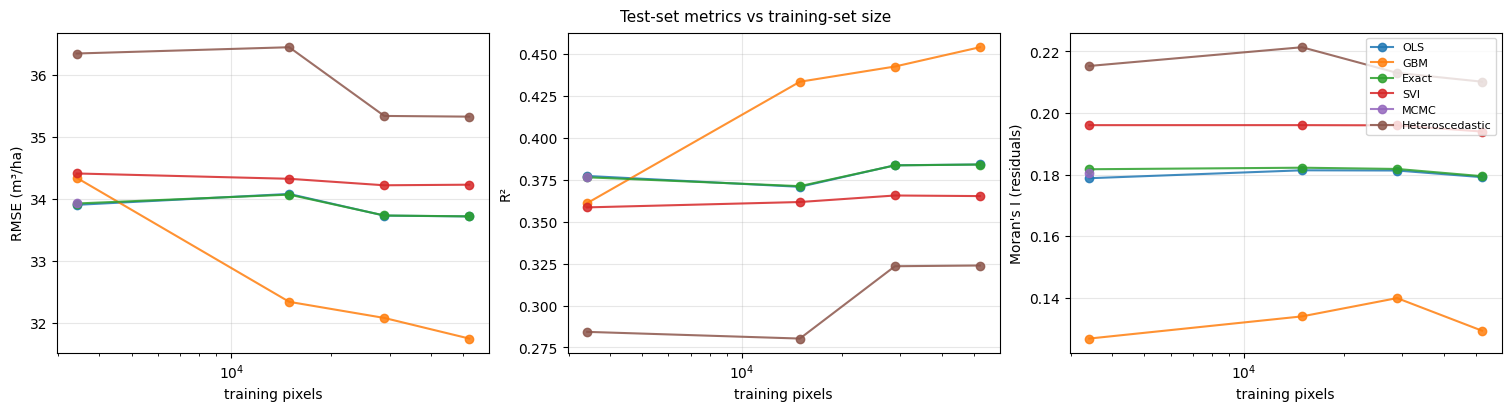

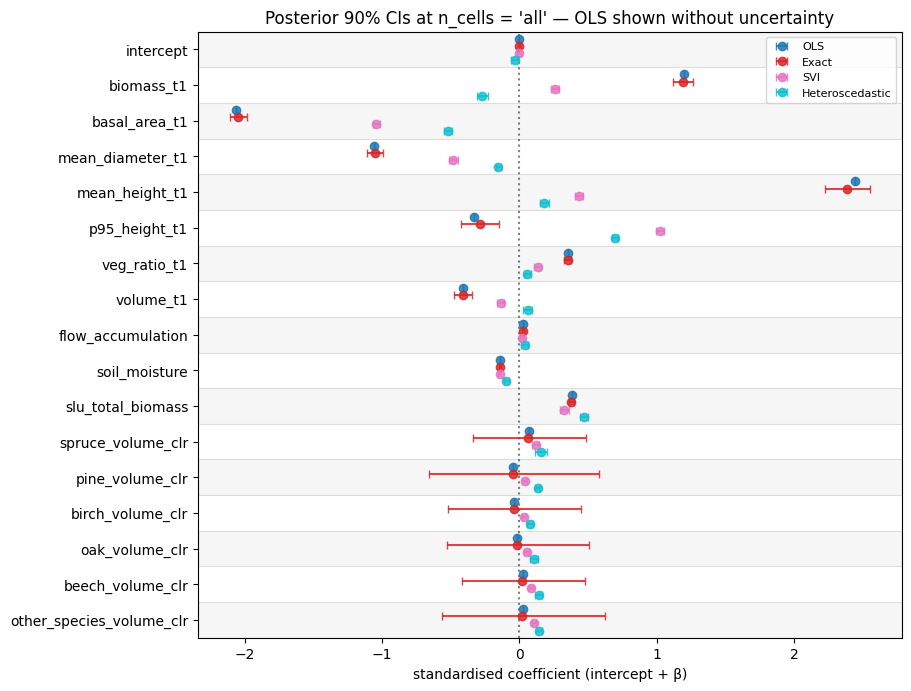

In [13]:
import matplotlib.pyplot as plt

# --- Unified metrics table ---
metrics_df = (
    all_metrics_df()
      .sort_values(["model", "n_train"])
      .reset_index(drop=True)
)
print(metrics_df.to_string(index=False, float_format=lambda v: f"{v:.3f}"))


# --- Figure 1: scaling axis (RMSE / R² / Moran's I vs training pixels) ---
panels = [("RMSE", "RMSE (m³/ha)"), ("R2", "R²"), ("MoranI", "Moran's I (residuals)")]
fig1, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
for ax, (metric, label) in zip(axes, panels):
    for model_name, by_n in MODELS.items():
        items = sorted(by_n.items(), key=lambda kv: by_n[kv[0]]["n_train"])
        xs = [v["n_train"] for _, v in items]
        ys = [v["metrics"][metric] for _, v in items]
        ax.plot(xs, ys, marker="o", label=model_name, alpha=0.85)
    ax.set_xscale("log")
    ax.set_xlabel("training pixels")
    ax.set_ylabel(label)
    ax.grid(True, alpha=0.3)
axes[-1].legend(loc="upper right", fontsize=8)
fig1.suptitle("Test-set metrics vs training-set size", fontsize=11)
plt.show()


# --- Figure 2: β posterior forest plot at n_cells = 'all' ---
# OLS contributes a single point (no uncertainty); the Bayesian models
# contribute posterior means + 90% credible intervals. MCMC may be
# missing at n_cells='all' if RUN_MCMC_FULL_GRID was False — that's fine,
# only the models with samples at this step are plotted.
target_step = "all"
feature_labels_full = ["intercept"] + FEATURE_NAMES
models_with_coefs = [
    m for m in MODELS
    if target_step in MODELS[m] and MODELS[m][target_step]["coefs_samples"] is not None
]
n_features = len(feature_labels_full)
n_models = len(models_with_coefs)

fig2, ax = plt.subplots(figsize=(9, max(5, 0.4 * n_features)), constrained_layout=True)

# Alternating row bands + faint separators so the eye can group markers by feature.
for i in range(0, n_features, 2):
    ax.axhspan(i - 0.5, i + 0.5, color="gray", alpha=0.07, zorder=0)
for i in range(n_features - 1):
    ax.axhline(i + 0.5, color="gray", alpha=0.25, linewidth=0.5, zorder=0)

offsets = np.linspace(-0.3, 0.3, n_models) if n_models > 1 else [0.0]
colors = plt.cm.tab10(np.linspace(0, 1, max(n_models, 2)))

for idx, model_name in enumerate(models_with_coefs):
    coefs = MODELS[model_name][target_step]["coefs_samples"]
    means = coefs.mean(axis=0)
    if coefs.shape[0] > 1:
        lo = np.quantile(coefs, 0.05, axis=0)
        hi = np.quantile(coefs, 0.95, axis=0)
    else:
        lo = hi = means
    y_pos = np.arange(n_features) + offsets[idx]
    ax.errorbar(means, y_pos, xerr=[means - lo, hi - means],
                fmt="o", capsize=3, color=colors[idx],
                label=model_name, alpha=0.85, zorder=2)
ax.axvline(0, color="k", linestyle=":", alpha=0.5, zorder=1)
ax.set_yticks(np.arange(n_features))
ax.set_yticklabels(feature_labels_full)
ax.set_ylim(n_features - 0.5, -0.5)  # invert + tighten to the rows
ax.set_xlabel("standardised coefficient (intercept + β)")
ax.set_title(
    f"Posterior 90% CIs at n_cells = {target_step!r} — OLS shown without uncertainty"
)
ax.legend(loc="best", fontsize=8)
plt.show()